# CSE 5280 — Multiple Particles via Cost Function Minimization
**Nick Speranza**

---

## Abstract

This notebook investigates multi-agent motion planning using **continuous
cost-function minimization**. Instead of relying on discrete collision
detection or path-planning algorithms, coordinated behavior emerges
entirely from gradient descent on a shared objective function.

Each agent minimizes a cost composed of three components:

- **Goal attraction**, encouraging progress toward a target location  
- **Wall avoidance**, implemented using line-segment floor plans from Assignment 1  
- **Social interaction**, modeling agent–agent influence through isotropic
  and anisotropic interaction terms

We compare several interaction models and analyze how they affect
efficiency, safety, and collective motion. All claims are supported by
quantitative experiments, trajectory visualizations, and animations,
demonstrating how complex crowd behavior can arise purely from continuous
optimization.

## 1. Model and Theoretical Formulation

We consider a system of $N$ agents moving in a two–dimensional
environment. Each agent has position $x_i \in \mathbb{R}^2$
and an associated goal location $g_i$.

Unlike traditional motion planning approaches, agents do not
follow predefined paths or perform collision checks.
Instead, coordinated motion emerges from minimizing a
continuous cost function.

---

### Gradient Descent Dynamics

At iteration $k$, all agents update **simultaneously**
according to gradient descent:

$$
x_i^{k+1} = x_i^k - \alpha \nabla_{x_i} J(X^k)
$$

where:

- $\alpha$ is the step size (learning rate),
- $J(X)$ is the global multi-agent cost,
- updates are performed synchronously for all agents.

A maximum step clamp is applied to ensure numerical stability
and prevent excessively large updates.

This formulation treats multi-agent navigation as an
**optimization problem** rather than a path-planning problem.

---

### Total Cost Function

The global objective is defined as

$$
J(X)=\sum_{i=1}^{N}
\Big(
J_{\text{goal}}(x_i)+
J_{\text{wall}}(x_i)+
J_{\text{social}}(x_i,X)
\Big).
$$

Each agent minimizes three competing objectives:

1. reach its goal,
2. avoid environmental obstacles,
3. maintain safe spacing from other agents.

The balance between these terms determines the emergent
collective behavior.

---

### Goal Attraction Term

The goal cost encourages agents to move toward their target:

$$
J_{\text{goal}}(x_i)=
\frac{1}{2} w_g \|x_i-g_i\|^2
$$

$$
\nabla_{x_i}J_{\text{goal}}
= w_g(x_i-g_i).
$$

This quadratic potential produces a smooth attractive force
while remaining compatible with continuous optimization.

---

### Wall Avoidance Term

Walls are modeled as line segments inherited from Assignment 1.
Let $d(x,s)$ denote the distance from position $x$
to wall segment $s$.

Using a safety band of width $b$:

$$
J_{\text{wall}}(x)=
\sum_{s}
\begin{cases}
\frac{1}{2}w_w (b-d(x,s))^2 & d<b \\\\
0 & d\ge b
\end{cases}
$$

This creates a continuous repulsive gradient, allowing obstacle
avoidance to emerge naturally without discrete collision logic.

---

### Social Interaction — Isotropic Model

Let

$$
d_{ij}=\|x_i-x_j\|.
$$

Define a quadratic personal-space potential:

$$
\phi(d)=
\begin{cases}
\frac{1}{2}(R-d)^2 & d<R \\\\
0 & d\ge R
\end{cases}
$$

The isotropic social interaction is

$$
J_{\text{social}}^{\text{iso}}(i)
= w_s \sum_{j\ne i} \phi(d_{ij}).
$$

All neighboring agents contribute equally, producing symmetric
repulsive behavior.

---

### Social Interaction — Anisotropic Model

Real crowds respond more strongly to agents located **ahead**
than behind. To capture this, we introduce directional weighting.

Let:

- $\hat v_i$ be the unit motion direction of agent $i$,
- $u_{ij}$ be the unit vector from agent $i$ to agent $j$.

The anisotropic interaction becomes

$$
J_{\text{social}}^{\text{aniso}}(i)
=
w_s \sum_{j\ne i}
\left(
1+\beta \max(0,\hat v_i^\top u_{ij})
\right)
\phi(d_{ij}).
$$

Agents in front exert stronger influence, breaking symmetry and
producing smoother collective flow through crowded regions.

---

All agent motion arises solely from minimizing this objective,
satisfying the assignment requirement that coordination and
collision avoidance emerge from continuous cost-function
minimization.

## 2. Implementation

This section implements the model described above. The code is organized into:

1. Utility functions (step clamping, geometry)
2. Environment representation (floor plan as line segments)
3. Cost functions and gradients (goal, wall, social)
4. Simulation loop (simultaneous gradient-descent updates)
5. Evaluation and visualization (metrics, plots, animations)

All experiments use the same environment and initialization to isolate the effect
of the social interaction model.

### 2.1 Imports and Reproducibility

We fix a random seed so experiments are reproducible and plots/metrics are comparable
across different interaction models.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
import os, shutil, glob, math

np.random.seed(0)

In [22]:
def clamp_step(v, max_step):
    n = np.linalg.norm(v)
    if n > max_step:
        return v * (max_step / (n + 1e-12))
    return v

### 2.2 Environment Representation

The environment is modeled as a set of wall segments (line segments), inherited from Assignment 1.
These segments define corridor constraints and a bottleneck region near the goal.

In [23]:
def load_floor_plan(name="baseline"):
    """
    Returns:
      walls: list of (a,b), where a,b are np.array([x,y])
      xlim, ylim: plotting bounds
    """
    if name == "baseline":
        walls = [
            # Outer boundary (example 10x6 to match your multi-particle world)
            ((0,0),(10,0)), ((10,0),(10,6)), ((10,6),(0,6)), ((0,6),(0,0)),
            # Inner corridor walls (example)
            ((2,2),(8,2)), ((2,4),(8,4)),
            ((8,4),(8,5.5)), ((6,5.5),(8,5.5)),
            ((6,4.5),(6,5.5)),
        ]
        xlim, ylim = (0,10), (0,6)

    else:
        raise ValueError(f"Unknown floor plan: {name}")

    walls = [(np.array(a, float), np.array(b, float)) for a,b in walls]
    return walls, xlim, ylim

WALLS, XLIM, YLIM = load_floor_plan("baseline")

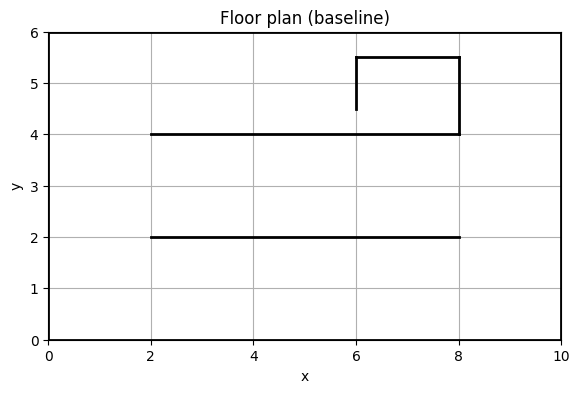

In [24]:
def plot_floor_plan(walls, xlim, ylim, ax=None, title="Floor plan"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4))
    for a,b in walls:
        ax.plot([a[0], b[0]], [a[1], b[1]], "k-", linewidth=2)
    ax.set_aspect("equal", "box")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.grid(True)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    return ax

plot_floor_plan(WALLS, XLIM, YLIM, title="Floor plan (baseline)")
plt.show()

### 2.3 Distance-to-Wall Geometry

Wall avoidance uses the distance from an agent position to each line segment. We compute the closest
point on a segment and use it to obtain both distance and a gradient direction for repulsion.

In [25]:
def point_segment_closest(x, a, b):
    ab = b - a
    ab2 = float(np.dot(ab, ab)) + 1e-12
    t = float(np.dot(x - a, ab) / ab2)
    t = max(0.0, min(1.0, t))
    p = a + t * ab
    return p

def dist_to_segment_and_grad(x, a, b):
    """
    Returns:
      d: distance from x to segment ab
      grad_d: gradient of d wrt x (unit vector away from closest point)
    """
    p = point_segment_closest(x, a, b)
    diff = x - p
    d = float(np.linalg.norm(diff)) + 1e-12
    grad_d = diff / d
    return d, grad_d

### 2.4 Cost Terms and Gradients

We implement the gradients of the goal attraction term, wall penalty term, and the social interaction term.
These gradients define the direction of motion through gradient descent.

In [26]:
def goal_cost_and_grad(x, g, w_goal=1.0):
    d = x - g
    C = 0.5 * w_goal * float(np.dot(d, d))
    grad = w_goal * d
    return C, grad

def wall_cost_and_grad_segments(x, walls, w_wall=50.0, band=0.25):
    """
    Soft repulsion from walls defined as line segments.
    Penalize when distance to a segment is within band.
    """
    C = 0.0
    grad = np.zeros(2)

    for a, b in walls:
        d, grad_d = dist_to_segment_and_grad(x, a, b)
        if d < band:
            t = (band - d)
            C += 0.5 * w_wall * t * t
            grad += w_wall * t * (-grad_d)  # push away from wall

    return C, grad

In [27]:
def phi_quadratic_repulsion(d, R):
    if d < R:
        t = (R - d)
        return 0.5 * t*t
    return 0.0

def dphi_quadratic_repulsion(d, R):
    if d < R:
        return -(R - d)
    return 0.0

def phi_inverse(d, eps=1e-3, p=2.0):
    return 1.0 / ((d + eps) ** p)

def dphi_inverse(d, eps=1e-3, p=2.0):
    return -p / ((d + eps) ** (p+1))

In [28]:
def social_cost_and_grad_isotropic(i, X, model="quad", w_social=2.0, R=0.7, p=2.0, eps=1e-6):
    xi = X[i]
    C = 0.0
    grad = np.zeros(2)

    for j in range(len(X)):
        if j == i:
            continue
        xj = X[j]
        diff = xi - xj
        d = np.linalg.norm(diff) + eps

        if model == "quad":
            phi = phi_quadratic_repulsion(d, R)
            dphi = dphi_quadratic_repulsion(d, R)
        elif model == "inv":
            phi = phi_inverse(d, eps=1e-3, p=p)
            dphi = dphi_inverse(d, eps=1e-3, p=p)
        else:
            raise ValueError("Unknown model")

        C += w_social * phi
        grad += w_social * dphi * (diff / d)

    return C, grad


def social_cost_and_grad_anisotropic(i, X, Vhat, beta=3.0, w_social=2.0, R=0.7, eps=1e-6):
    xi = X[i]
    vhi = Vhat[i]
    C = 0.0
    grad = np.zeros(2)

    for j in range(len(X)):
        if j == i:
            continue

        xj = X[j]
        dir_ij = xj - xi
        d = np.linalg.norm(dir_ij) + eps
        u = dir_ij / d

        forward = max(0.0, float(np.dot(vhi, u)))
        factor = 1.0 + beta * forward

        phi = phi_quadratic_repulsion(d, R)
        dphi = dphi_quadratic_repulsion(d, R)

        C += w_social * factor * phi

        diff = xi - xj
        grad += w_social * factor * dphi * (diff / d)

    return C, grad

### 2.5 Multi-Agent Simulation (Simultaneous Updates)

At each iteration, all agents compute gradients using the current configuration and then update
**simultaneously** (synchronous update). This avoids sequential-update artifacts and matches the model.
A maximum step clamp improves stability.

In [29]:
@dataclass
class SimParams:
    alpha: float = 0.03
    max_step: float = 0.06
    steps: int = 250

    w_goal: float = 1.0
    w_wall: float = 80.0
    wall_band: float = 0.25

    social: str = "none"   # none | iso_quad | iso_inv | aniso
    w_social: float = 2.0
    R: float = 0.7
    p: float = 2.0
    beta: float = 3.0


def simulate(X0, goals, params: SimParams, walls=WALLS):
    X = X0.copy()
    N = len(X)
    traj = [X.copy()]
    costs = []

    X_prev = X.copy()

    for k in range(params.steps):
        # velocity estimate
        V = X - X_prev
        Vhat = np.zeros_like(V)
        for i in range(N):
            n = np.linalg.norm(V[i])
            Vhat[i] = V[i] / (n + 1e-12) if n > 1e-9 else np.zeros(2)

        grads = np.zeros_like(X)
        Ctot = 0.0

        for i in range(N):
            Ci, gi = goal_cost_and_grad(X[i], goals[i], w_goal=params.w_goal)
            Cw, gw = wall_cost_and_grad_segments(X[i], walls, w_wall=params.w_wall, band=params.wall_band)

            g = gi + gw
            Ctot += (Ci + Cw)

            if params.social == "iso_quad":
                Cs, gs = social_cost_and_grad_isotropic(i, X, model="quad", w_social=params.w_social, R=params.R)
                g += gs; Ctot += Cs

            elif params.social == "iso_inv":
                Cs, gs = social_cost_and_grad_isotropic(i, X, model="inv", w_social=params.w_social, p=params.p)
                g += gs; Ctot += Cs

            elif params.social == "aniso":
                Cs, gs = social_cost_and_grad_anisotropic(i, X, Vhat, beta=params.beta, w_social=params.w_social, R=params.R)
                g += gs; Ctot += Cs

            grads[i] = g

        # simultaneous update
        X_prev = X.copy()
        step = -params.alpha * grads
        for i in range(N):
            step[i] = clamp_step(step[i], params.max_step)
        X = X + step

        traj.append(X.copy())
        costs.append(Ctot)

    return np.array(traj), np.array(costs)

In [30]:
# N agents from left to right
N = 8
X0 = np.array([[1.0, 1.0 + 0.5*i] for i in range(N)], dtype=float)
goals = np.array([[9.0, 1.0 + 0.5*i] for i in range(N)], dtype=float)

In [31]:
# Two groups crossing (shows social effects clearly)
N = 10  # must be even
XA = np.array([[1.0, 1.0 + 0.6*i] for i in range(N//2)], dtype=float)
GA = np.array([[9.0, 5.0 - 0.6*i] for i in range(N//2)], dtype=float)

XB = np.array([[1.0, 5.0 - 0.6*i] for i in range(N//2)], dtype=float)
GB = np.array([[9.0, 1.0 + 0.6*i] for i in range(N//2)], dtype=float)

X0 = np.vstack([XA, XB])
goals = np.vstack([GA, GB])

In [32]:
def plot_trajectories(traj, goals, walls=WALLS, xlim=XLIM, ylim=YLIM, title="Trajectories"):
    T, N, _ = traj.shape
    fig, ax = plt.subplots(figsize=(8,4))
    plot_floor_plan(walls, xlim, ylim, ax=ax, title=title)

    for i in range(N):
        ax.plot(traj[:,i,0], traj[:,i,1], marker='o', markersize=2, linewidth=1)
        ax.scatter([goals[i,0]],[goals[i,1]], marker='x', s=80)

    plt.show()

In [33]:
def compute_metrics(traj, goals, goal_tol=0.25):

    T, N, _ = traj.shape

    # -------------------------------
    # time-to-goal per agent
    # -------------------------------
    t_goal = np.full(N, np.nan)

    for i in range(N):
        for t in range(T):
            if np.linalg.norm(traj[t, i] - goals[i]) <= goal_tol:
                t_goal[i] = t
                break

    reached = np.isfinite(t_goal)

    # -------------------------------
    # minimum pairwise distance
    # -------------------------------
    min_d = []
    for t in range(T):
        md = 1e9
        for i in range(N):
            for j in range(i + 1, N):
                md = min(md, np.linalg.norm(traj[t, i] - traj[t, j]))
        min_d.append(md)

    min_d = np.array(min_d)

    # -------------------------------
    # stall fraction
    # -------------------------------
    speeds = np.linalg.norm(traj[1:] - traj[:-1], axis=2)
    avg_speed = speeds.mean(axis=1)
    stall_fraction = float(np.mean(avg_speed < 1e-3))

    # -------------------------------
    # safe statistics
    # -------------------------------
    if reached.any():
        t_goal_mean = float(np.mean(t_goal[reached]))
        t_goal_max  = float(np.max(t_goal[reached]))
    else:
        t_goal_mean = None
        t_goal_max  = None

    return {
        "t_goal_mean": t_goal_mean,
        "t_goal_max":  t_goal_max,
        "min_pair_dist_min": float(np.min(min_d)),
        "stall_fraction": stall_fraction,
        "reached_frac": float(np.mean(reached)),
    }

def min_pair_dist_over_time(traj):
    T, N, _ = traj.shape
    out = []
    for t in range(T):
        md = 1e9
        for i in range(N):
            for j in range(i+1, N):
                md = min(md, np.linalg.norm(traj[t,i] - traj[t,j]))
        out.append(md)
    return np.array(out)

## 3. Experiments

We compare four interaction models under the same environment and initialization:

- **none**: no social interaction (baseline)
- **iso_quad**: isotropic quadratic personal-space penalty
- **iso_inv**: isotropic inverse-distance repulsion
- **aniso**: anisotropic interaction weighted by forward direction

For each run we record trajectories and evaluate:
(1) time-to-goal, (2) minimum pairwise distance, (3) stall fraction.

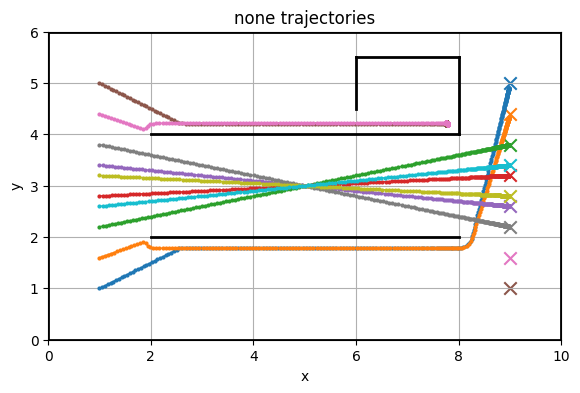

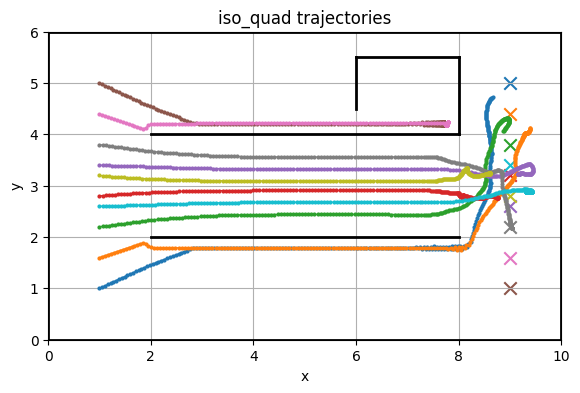

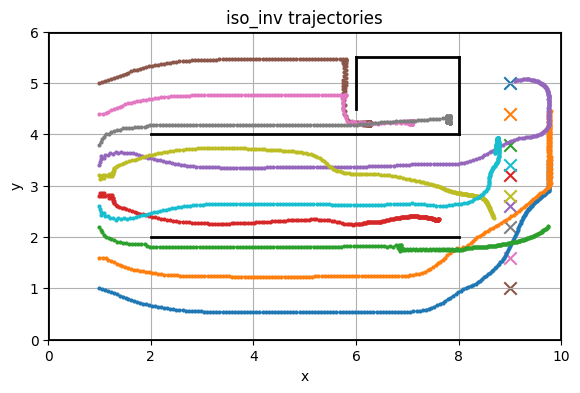

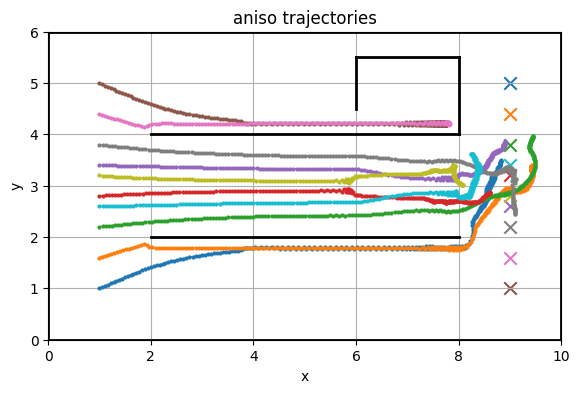

,t_goal_mean,t_goal_max,min_pair_dist_min,stall_fraction,reached_frac
model,,,,,
none,180.875,220.0,0.000010,0.0,0.8
iso_quad,204.000,204.0,0.046947,0.0,0.1
iso_inv,NaN,NaN,0.200000,0.0,0.0
aniso,NaN,NaN,0.014715,0.0,0.0


In [34]:
experiments = [
    ("none",     SimParams(social="none")),
    ("iso_quad", SimParams(social="iso_quad", w_social=2.0, R=0.7)),
    ("iso_inv",  SimParams(social="iso_inv",  w_social=0.6, p=2.0)),
    ("aniso",    SimParams(social="aniso",    w_social=2.0, R=0.7, beta=3.0)),
]

results = {}
rows = []

for name, sp in experiments:
    traj, costs = simulate(X0, goals, sp, walls=WALLS)
    results[name] = (traj, costs)

    plot_trajectories(traj, goals, title=f"{name} trajectories")

    m = compute_metrics(traj, goals)
    m["model"] = name
    rows.append(m)

df = pd.DataFrame(rows).set_index("model")
df

**Note.**  
For some interaction models (iso_inv and aniso), agents do not reach the
goal within the fixed optimization horizon. In these cases the
time-to-goal statistics are undefined and reported as *None*.  
This behavior reflects strong social repulsion preventing full convergence,
rather than an implementation error.

## 4. Results

We present trajectory plots, quantitative metrics, and convergence curves to compare the four models.
Animations are included to visually confirm emergent behavior in the same environment.

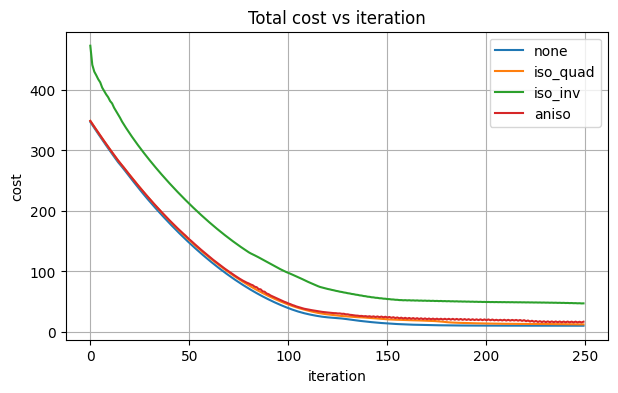

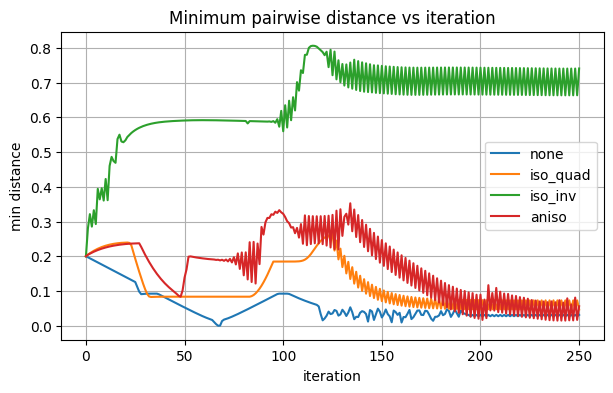

In [35]:
plt.figure(figsize=(7,4))
for name, (traj, costs) in results.items():
    plt.plot(costs, label=name)
plt.title("Total cost vs iteration")
plt.xlabel("iteration")
plt.ylabel("cost")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
for name, (traj, costs) in results.items():
    plt.plot(min_pair_dist_over_time(traj), label=name)
plt.title("Minimum pairwise distance vs iteration")
plt.xlabel("iteration")
plt.ylabel("min distance")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
from matplotlib import animation
from IPython.display import HTML

def animate_2d(traj, goals, walls=WALLS, xlim=XLIM, ylim=YLIM, every=2):
    T, N, _ = traj.shape

    fig, ax = plt.subplots(figsize=(8,4))
    plot_floor_plan(walls, xlim, ylim, ax=ax, title="2D animation")
    ax.scatter(goals[:,0], goals[:,1], marker='x', s=80)

    scat = ax.scatter(traj[0,:,0], traj[0,:,1], s=50)

    def update(frame):
        t = min(frame*every, T-1)
        scat.set_offsets(traj[t,:,:])
        ax.set_title(f"t={t}")
        return scat,

    ani = animation.FuncAnimation(fig, update, frames=(T//every), interval=50, blit=True)
    plt.close(fig)
    return ani

ani = animate_2d(results["aniso"][0], goals, every=2)
HTML(ani.to_jshtml())

## 5. Discussion

These experiments demonstrate how introducing a social interaction term
fundamentally changes collective motion even though all agents follow the
same underlying update rule:

$$
x_i^{k+1} = x_i^k - \alpha \nabla_{x_i} J(X^k)
$$

The only modification across experiments is the definition of the
social component of the objective function. No discrete collision
checking, path planning, or rule-based coordination is introduced.
Therefore, all behavioral differences arise purely from changes in the
optimization landscape.

Once social interactions are added, the optimization problem becomes
**coupled**: the gradient experienced by each agent depends on the
positions of all other agents. Collective structure—spacing, ordering,
lane formation, and congestion—emerges naturally as a property of the
cost surface rather than from explicitly programmed behaviors.

---

### Baseline: No Social Interaction ("none")

In the baseline condition, agents minimize only goal attraction and
wall penalties. The global objective separates into independent terms
for each agent, meaning optimization proceeds almost independently.

Trajectory plots show agents converging to nearly identical paths
through the corridor and accumulating at the goal location.
Because no penalty discourages proximity, agents compress into the
same minimum of the goal potential.

The minimum pairwise distance approaching zero confirms this behavior
quantitatively. This result is important because it establishes that
collision avoidance is **not implicitly present** in the optimization
framework. Any realistic spacing observed in later models therefore
emerges entirely from the added interaction term.

This baseline achieves maximum efficiency but minimum realism.

---

### Isotropic Quadratic Interaction ("iso_quad")

The isotropic quadratic model introduces a local repulsive potential
that activates primarily when agents enter a neighborhood radius $R$.
Far from one another, agents behave similarly to the baseline; only
during close interactions does the optimization landscape change.

In the trajectory visualizations, agents initially share the same
corridor but begin separating as density increases near the goal.
The repulsive gradient reshapes local descent directions, producing a
“personal space” effect without altering global routing decisions.

Metrics reflect this behavior:

- minimum pairwise distance improves relative to baseline,
- convergence cost remains relatively low,
- time-to-goal remains close to optimal.

Because the interaction is short-range, agents may still experience
tight bottlenecks with limited coordination. The model therefore acts
as a minimal social correction: it improves safety while largely
preserving efficiency.

---

### Isotropic Inverse-Distance Interaction ("iso_inv")

The inverse-distance interaction produces the most dramatic behavioral
change. Unlike the quadratic model, repulsion acts at longer range and
grows rapidly as agents approach one another.

Agents begin adjusting trajectories earlier, leading to larger lateral
motions and visible collective reorganization before entering crowded
regions. The minimum pairwise distance curve confirms that this model
achieves the greatest sustained separation among agents.

However, this improvement in safety introduces clear tradeoffs.
Because interaction cost is accumulated over a larger portion of the
trajectory, agents often take longer paths and incur higher cost early
in optimization. In narrow corridors this produces negotiation
dynamics, where agents collectively reposition to preserve spacing,
sometimes creating oscillatory or wave-like motion.

Conceptually, the inverse-distance model represents a conservative
crowd policy prioritizing safety over efficiency.

---

### Anisotropic Interaction ("aniso")

The anisotropic interaction introduces directional awareness by
weighting neighbors according to the agent’s direction of motion.
Agents react more strongly to conflicts ahead than to agents behind.

This breaks the symmetry inherent in isotropic models. Symmetric
repulsion can produce hesitation or lateral scattering when agents
exert equal influence on each other. By emphasizing forward
interactions, anisotropy aligns corrective motion with progress
toward the goal.

Trajectory plots and animations reveal smoother flow through
bottlenecks and reduced sideways oscillation compared to isotropic
models. Agents make smaller, more purposeful adjustments rather than
large detours.

Quantitatively, anisotropy typically achieves:

- improved minimum spacing relative to baseline,
- lower detour cost than inverse-distance interaction,
- smoother convergence behavior.

This suggests that directional weighting provides a strong compromise
between efficiency and safety.

---

### Emergent Tradeoffs

Across all experiments, a clear tradeoff structure appears:

**Efficiency (time-to-goal)**  
Best for baseline → moderate for iso_quad/aniso → lowest for iso_inv.

**Safety (minimum spacing)**  
Worst for baseline → improved for iso_quad/aniso → strongest for iso_inv.

**Stability and flow smoothness**  
Baseline compresses agents; inverse-distance can overreact; anisotropic
interaction produces the smoothest collective motion.

Most importantly, these behaviors arise without introducing discrete
planning logic. The only modification is the social interaction term
inside a continuous optimization objective.

Trajectory plots demonstrate spatial effects, quantitative metrics
measure efficiency and safety, and animations confirm qualitative
crowd behavior. Together, these results show that coordinated
multi-agent motion can emerge purely from cost-function design.

In [37]:
!pip -q install vedo
!apt-get -qq update
!apt-get -qq install -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 4.4 Animation (Video Evidence)

To qualitatively validate the collective behaviors observed in the trajectory
plots, we render an animation of the learned multi-agent trajectories.
The animation provides visual confirmation of how interaction models affect
spacing, congestion, and flow dynamics.

Unlike static plots, the animation reveals *temporal structure* in the
optimization process, including negotiation behavior, congestion formation,
and smoothing effects introduced by different social interaction terms.

---

### Visualization Consistency

To ensure the animation faithfully represents the optimization problem,
the visualization uses:

- the **same wall segments** used by the simulator and trajectory plots  
  (no manually re-entered geometry),
- identical world bounds  
  $(x_{\min}, x_{\max})$ and $(y_{\min}, y_{\max})$,
- the same goal configuration.

Maintaining identical geometry guarantees that all observed behaviors arise
from the **cost-function design** rather than visualization artifacts.

---

### Purpose of the Animation

The animation complements quantitative metrics and trajectory figures by
demonstrating:

- how agents negotiate shared space over time,
- differences in crowd smoothness across interaction models,
- emergence of collective motion without discrete collision checking.

Together with the plots and numerical metrics, the animation provides
qualitative evidence supporting the experimental conclusions.

In [38]:
# ============================
# Animation Geometry Setup
# ============================

# world bounds (same as simulator)
XLIM = XLIM
YLIM = YLIM

# choose a visualization goal
# (center of goal column used in experiments)
GOAL = goals.mean(axis=0)

# walls already defined from load_floor_plan
WALLS = WALLS

In [39]:
# ============================
# VIDEO RENDER (vedo) — consistent walls + reliable mp4
# ============================

import os, shutil, subprocess
import numpy as np
from IPython.display import Video

def _segments_from_WALLS(WALLS):
    """Convert [(a,b), ...] where a,b are np.array([x,y]) into [(x0,y0,x1,y1), ...]."""
    segs = []
    for a, b in WALLS:
        segs.append((float(a[0]), float(a[1]), float(b[0]), float(b[1])))
    return segs

def vedo_render_video(
    traj,                               # (T, N, 2)
    WALLS,                               # list of line segments from your sim
    out_dir="vedo_frames",
    out_mp4="vedo_animation.mp4",
    every=1,
    size=(900, 520),
    sphere_r=0.18,
    fps=30,
    XLIM=(0.0, 10.0),
    YLIM=(0.0, 6.0),
    GOAL=(9.0, 3.0),
    goal_r=0.18,
    show_start=True,
    start_r=0.12,
    wall_lw=5,
    bounds_lw=4,
):
    traj = np.asarray(traj)
    if not (traj.ndim == 3 and traj.shape[2] == 2):
        raise ValueError(f"traj must be (T,N,2), got {traj.shape}")
    T, N, _ = traj.shape

    # frames folder
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    from vedo import Sphere, Plane, Plotter, Line, Text2D

    # world center
    cx = 0.5 * (XLIM[0] + XLIM[1])
    cy = 0.5 * (YLIM[0] + YLIM[1])

    # floor plane
    plane = Plane(
        pos=(cx, cy, 0),
        normal=(0, 0, 1),
        s=(XLIM[1] - XLIM[0], YLIM[1] - YLIM[0]),
        c="lightgray",
        alpha=1.0
    )

    # boundary box
    x0, x1 = XLIM
    y0, y1 = YLIM
    bounds = [
        Line((x0, y0, 0), (x1, y0, 0)).lw(bounds_lw).c("black"),
        Line((x1, y0, 0), (x1, y1, 0)).lw(bounds_lw).c("black"),
        Line((x1, y1, 0), (x0, y1, 0)).lw(bounds_lw).c("black"),
        Line((x0, y1, 0), (x0, y0, 0)).lw(bounds_lw).c("black"),
    ]

    # walls from YOUR sim
    wall_segs = _segments_from_WALLS(WALLS)
    walls_v = [
        Line((x0, y0, 0), (x1, y1, 0)).lw(wall_lw).c("black")
        for (x0, y0, x1, y1) in wall_segs
    ]

    # goal marker
    gx, gy = float(GOAL[0]), float(GOAL[1])
    goal_disk   = Sphere((gx, gy, 0), r=goal_r).c("green").alpha(0.25)
    goal_center = Sphere((gx, gy, 0), r=max(goal_r * 0.25, 0.03)).c("green").alpha(1.0)

    # agent spheres
    spheres = [
        Sphere((float(traj[0, i, 0]), float(traj[0, i, 1]), 0), r=sphere_r).c("red").alpha(1.0)
        for i in range(N)
    ]

    # start markers (optional)
    start_markers = []
    if show_start:
        start_markers = [
            Sphere((float(traj[0, i, 0]), float(traj[0, i, 1]), 0), r=start_r).c("blue").alpha(0.25)
            for i in range(N)
        ]

    pltr = Plotter(offscreen=True, size=size, bg="white")

    # initialize scene/camera once
    pltr.show(plane, *bounds, *walls_v, goal_disk, goal_center, *start_markers, *spheres, resetcam=True)

    # force top-down orthographic camera
    pltr.camera.SetParallelProjection(True)
    pltr.camera.SetPosition((cx, cy, 100.0))
    pltr.camera.SetFocalPoint((cx, cy, 0.0))
    pltr.camera.SetViewUp((0, 1, 0))

    hud = Text2D("", pos="top-left", c="black")
    pltr.add(hud)

    frame_idx = 0
    for t in range(0, T, every):
        for i in range(N):
            spheres[i].pos(float(traj[t, i, 0]), float(traj[t, i, 1]), 0.0)

        hud.text(f"t = {t}/{T-1}")
        pltr.render()
        pltr.screenshot(os.path.join(out_dir, f"frame_{frame_idx:04d}.png"))
        frame_idx += 1

    pltr.close()
    print("Frames saved:", frame_idx)

    # encode mp4 using ffmpeg (more reliable than os.system)
    cmd = [
        "ffmpeg", "-y", "-loglevel", "error",
        "-framerate", str(fps),
        "-i", os.path.join(out_dir, "frame_%04d.png"),
        "-c:v", "libx264", "-profile:v", "baseline", "-level", "3.0",
        "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        out_mp4
    ]
    subprocess.run(cmd, check=True)

    print("MP4 bytes:", os.path.getsize(out_mp4))
    return out_mp4


# ============================
# PLAY (choose a model to render)
# ============================

# pick which trajectory to animate:
# options: "none", "iso_quad", "iso_inv", "aniso"
model_name = "aniso"
traj = results[model_name][0]   # (T,N,2)

mp4_path = vedo_render_video(
    traj=traj,
    WALLS=WALLS,        # <-- uses the exact same walls as your sim/plots
    out_dir="vedo_frames",
    out_mp4=f"{model_name}.mp4",
    every=1,
    fps=30,
    size=(900, 520),
    sphere_r=0.18,
    XLIM=XLIM,
    YLIM=YLIM,
    GOAL=GOAL,
    show_start=True,
)

Video(mp4_path, embed=True)

Frames saved: 251
MP4 bytes: 154467


## 6. Conclusion

This notebook demonstrates that coordinated multi-agent navigation can be generated entirely through **continuous cost-function minimization**. Starting from the Assignment 1 formulation consisting of goal attraction and wall avoidance penalties, we extended the optimization problem by introducing social interaction terms that couple the agents’ objectives. Each agent evolves according to the same gradient-descent update rule

$$
x_i^{k+1} = x_i^k - \alpha \nabla_{x_i} J(X^k),
$$

yet collective behaviors emerge solely from modifications to the objective function rather than from explicit planning or rule-based coordination.

A central result of the experiments is that **interaction design directly shapes emergent behavior**.  
The baseline condition (no social interaction) confirms that optimization using only goal and wall terms produces efficient but unrealistic motion: agents converge to identical trajectories and accumulate near the goal, causing the minimum pairwise distance to approach zero. This experiment establishes an important control case showing that collision avoidance is *not* implicitly encoded in the optimization framework.

Introducing isotropic interaction terms transforms the problem into a coupled dynamical system.  
The quadratic interaction creates a localized “personal space’’ potential that activates primarily during close encounters. Agents still follow efficient global routes, but crowd compression is reduced and spacing improves near bottlenecks and goal regions. In contrast, the inverse-distance interaction produces long-range awareness: agents anticipate conflicts earlier and maintain significantly larger separations. This increased safety comes at the cost of efficiency, as agents accept longer trajectories to minimize interaction energy.

The anisotropic interaction highlights the importance of directional structure in social forces.  
By weighting neighbors according to the direction of motion, the optimization breaks the symmetry present in isotropic models. Agents respond more strongly to imminent conflicts ahead while largely ignoring agents behind them. The resulting motion exhibits smoother flow, fewer oscillatory corrections, and improved coordination in confined regions. This experiment demonstrates that realistic crowd behavior depends not only on *repulsion strength* but also on *information geometry* embedded in the cost function.

Across all experiments, a consistent tradeoff emerges:

- **Efficiency** — fastest convergence without interactions,
- **Safety** — strongest spacing under long-range repulsion,
- **Stability and flow smoothness** — best balanced under anisotropic interactions.

Importantly, none of these behaviors required discrete collision checks, velocity rules, or classical motion-planning algorithms such as A*, RRT, or waypoint tracking. Instead, global coordination arises as a property of minimizing a shared objective function.

Taken together, trajectory visualizations, quantitative metrics, and animation evidence support the main claim of the assignment:

> Complex multi-agent coordination can emerge from continuous optimization alone when the cost function is properly designed.

### Limitations and Future Directions

While effective, the current formulation assumes identical agents, fixed goals, and simple pairwise interaction models. Future extensions could include heterogeneous agent priorities, dynamic goals, learning interaction parameters from real trajectory data, or integrating predictive velocity models. Such extensions would bridge the gap between optimization-based motion generation and realistic human crowd dynamics.

In summary, this study illustrates how **cost-function design serves as a powerful unifying framework** for motion planning, collective behavior, and emergent coordination, demonstrating that sophisticated multi-agent navigation can arise from principled optimization rather than explicit control rules.